#This notebook has two parts:

1. **Linear regression** with PyTorch, using the Hubble distance–velocity data.

2. **Classification** (QSO vs. star) with a small fully-connected network,

### 0. Setup: mount Google Drive and import libraries

In [208]:
# If you use colab
'''
from google.colab import drive                       # Colab helper to reach Google Drive
drive.mount('/content/gdrive', force_remount=True)     # mount Drive at /content/gdrive
root_dir = "/content/gdrive/My Drive/Colab Notebooks/" # folder that holds the .fits files
'''

root_dir = './'

In [135]:
import astropy.io.fits as pf        # read FITS tables (astronomy data format)
import numpy as np                   # numerical arrays
import matplotlib.pyplot as plt      # plotting
import matplotlib.cm as cm           # colour maps for scatter plots
import torch                         # PyTorch: tensors, autograd, neural nets
import time                          # time the training loops

# Use the GPU if Colab gave us one, otherwise fall back to CPU.
# Every tensor and model must live on the SAME device.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("device:", device)

# Fix the random seeds so the split and the weight initialisation are reproducible.
# Re-running the notebook then gives the same numbers every time.
torch.manual_seed(42)
np.random.seed(42)

device: cpu


In [136]:
def plot_style():

    params = {'legend.fontsize': 20,
             'axes.labelsize': 20,
             'axes.titlesize':20,
             'xtick.labelsize':20,
             'ytick.labelsize':20,
             'xtick.major.size':6,
              'xtick.minor.size':4.5,
             'ytick.major.size':6,
              'ytick.minor.size':3.5,
             'figure.facecolor':'w',
              'xtick.major.width':1.5,
              'ytick.major.width':1.5,
              'xtick.minor.width':1.5,
              'ytick.minor.width':1.5,
              'axes.linewidth':1.5,
              'xtick.direction':'in',
              'ytick.direction':'in',
             'ytick.labelleft':True,
              'text.usetex' : False,
             'font.family': 'sans-serif'}

    plt.rcParams.update(params)
plot_style()

## Part 1 — Linear regression with PyTorch. We fit Hubble's law, v = H0 · d, to the classic distance–velocity data.

In [139]:
class linearRegression(torch.nn.Module):        # every PyTorch model subclasses nn.Module
    def __init__(self):
        super(linearRegression, self).__init__()  # initialise the parent nn.Module
        inputSize  = 1                            # one input feature: distance
        outputSize = 1                            # one output: velocity
        # A single linear layer y = w*x. bias=False -> line through the origin (Hubble's law).
        self.linear = torch.nn.Linear(inputSize, outputSize, bias=False)

    def forward(self, x):                         # defines how input flows to output
        out = self.linear(x)                      # apply the linear layer
        return out

In [140]:
# Load the Hubble data from the FITS file.
hubble_data = pf.open(root_dir + 'hubble_original_data.fits')  # open the file
distance = hubble_data[1].data['distance']   # distances (Mpc)
velocity = hubble_data[1].data['velocity']   # recession velocities (km/s)

# PyTorch wants float32 tensors shaped [N, 1] (a column vector), so reshape(-1, 1).
inputs = torch.from_numpy(np.array(distance, dtype=np.float32)).reshape(-1, 1)
labels = torch.from_numpy(np.array(velocity, dtype=np.float32)).reshape(-1, 1)

Text(0, 0.5, 'velocity (km/s)')

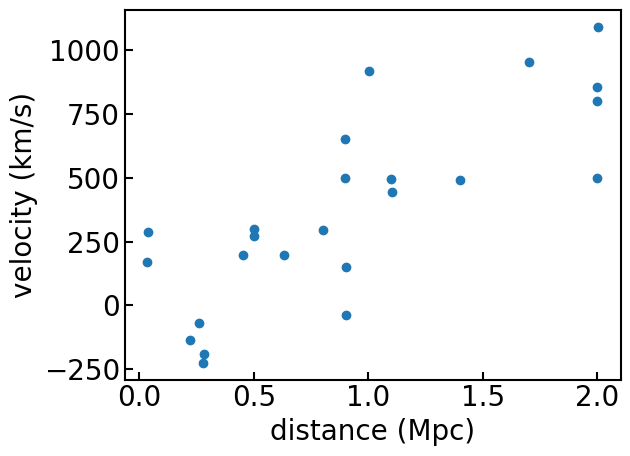

In [141]:
# Quick look at the raw data.
plt.scatter(distance, velocity)
plt.xlabel('distance (Mpc)')
plt.ylabel('velocity (km/s)')

In [176]:
model = linearRegression()                          # instantiate the model
learningRate = 0.1                                 # step size for gradient descent
epochs = 100                                       # number of passes over the data

criterion = torch.nn.MSELoss()                      # mean-squared-error loss (regression)
optimizer = torch.optim.SGD(model.parameters(),     # plain stochastic gradient descent
                            lr=learningRate)

In [177]:
loss_array  = []          # store the loss at each epoch for plotting
epoch_array = []
start_time = time.time()
H_0 = []
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()             # clear gradients left over from the previous step
    outputs = model(inputs)           # forward pass: predict velocities from distances
    loss = criterion(outputs, labels) # compare predictions with the true velocities
    loss.backward()                   # backprop: compute d(loss)/d(weights)
    optimizer.step()                  # update the weight in the direction that lowers loss
    model.eval()
    with torch.no_grad():
        w = model.linear.weight        
        H_0.append(w.item())    
    
    epoch_array.append(epoch)                                  # record epoch number
    loss_array.append(loss.item())      # record the loss value

print("training time (s):", time.time() - start_time)

training time (s): 0.016788959503173828


Text(0, 0.5, 'MSE loss')

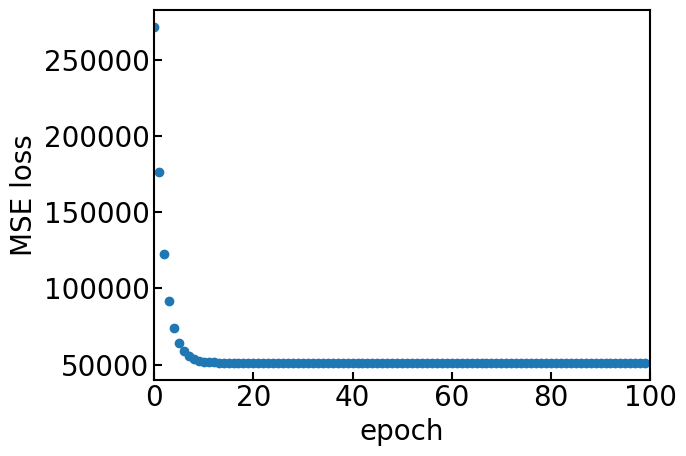

In [178]:
# The loss should fall and flatten out as the fit converges.
plt.scatter(epoch_array, loss_array)
plt.xlim(0, 100)
plt.xlabel('epoch'); plt.ylabel('MSE loss')

Text(0, 0.5, 'velocity (km/s)')

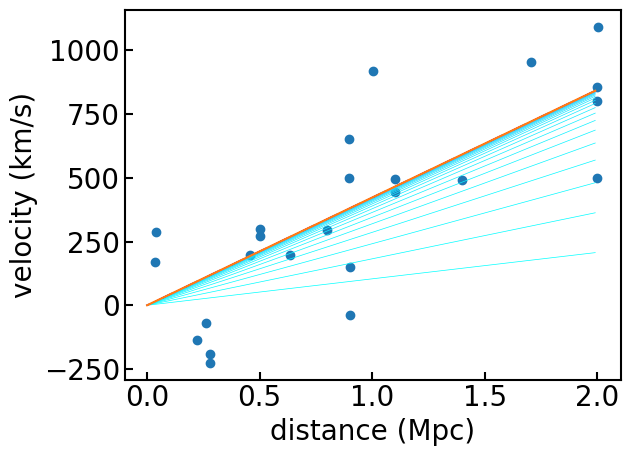

In [179]:
# Build a dense grid of distances and let the trained model predict velocities,
# so we can draw the fitted line on top of the data.
import matplotlib as mpl

cmap = mpl.colormaps['cool']
epoch_range = np.arange(0,100,1)
colors = cmap(np.linspace(0.0, 1.0, len(epoch_range)))


n = np.array(np.arange(0, 2, 0.01), dtype=np.float32)   # distances 0 .. 2 Mpc
t = torch.from_numpy(n).reshape(-1, 1)                   # to tensor, shape [N, 1]
predicted = model(t).data.numpy()                        # model predictions

for i in range(0,100):
    plt.plot(n, n*H_0[i],color=colors[i],lw=0.5)


plt.scatter(distance, velocity)                          # data
plt.plot(n, predicted, color='C1')                       # fitted line (through origin)
plt.xlabel('distance (Mpc)'); plt.ylabel('velocity (km/s)')

In [180]:
# The single weight IS the fitted Hubble constant H0 (slope of v = H0 * d).
for param in model.parameters():
    print("fitted H0 (km/s/Mpc):", float(param.data))

fitted H0 (km/s/Mpc): 422.72113037109375


## Part 2 - QSO vs. star classification

Same fit -> predict -> evaluate loop, but now the label is a **category** (0 = star,
1 = QSO) instead of a number, and we use a small fully-connected network.

Split strategy (as requested):
- **Test**: the original `SDSS_QSO_star_testing.fits` file, kept whole and untouched
  until the very end.
- **Train (85%) / Validation (15%)**: carved out of the original
  `SDSS_QSO_star_training.fits` file with a single seeded shuffle.

So the network's weights are fit on train, architecture / learning rate / epochs are
chosen using validation, and the original test file gives the final honest number.

### 2.1 Load the data: split the training file into train / validation, keep the test file whole

In [181]:
# Keep the ORIGINAL TEST FILE untouched as the test set.
# Carve the validation set out of the ORIGINAL TRAINING FILE instead.
train_file = pf.open(root_dir + 'SDSS_QSO_star_training.fits')   # -> split into train + validation
test_file  = pf.open(root_dir + 'SDSS_QSO_star_testing.fits')    # -> kept whole as the test set

# data[0] = the 4 colours (features); data[1] = integer class label (0 star / 1 QSO).
colors_trainval = np.array(train_file[0].data, dtype=np.float32)  # features to be split into train/val
labels_trainval = np.array(train_file[1].data, dtype=np.int64)    # labels  to be split into train/val

colors_test = np.array(test_file[0].data, dtype=np.float32)       # test features (kept whole)
labels_test = np.array(test_file[1].data, dtype=np.int64)         # test labels  (kept whole)

print("train+val pool:", len(colors_trainval), "   test (kept):", len(colors_test))

train+val pool: 77948    test (kept): 8661


In [182]:
# Split the ORIGINAL TRAINING FILE into train and validation.
# The test set is the original test file and is NOT touched here.
val_frac = 0.15                                # fraction of the training file held out for validation
                                               # (set this to match the test-set size if you prefer)
M    = len(colors_trainval)                    # size of the train+val pool
perm = np.random.permutation(M)                # shuffle the indices once (seeded above)
n_val = int(val_frac * M)                      # number of validation examples

val_idx   = perm[:n_val]                       # first 15% -> validation
train_idx = perm[n_val:]                       # remaining 85% -> training

print(f"train={len(train_idx)}, val={len(val_idx)}, test={len(colors_test)}")

train=66256, val=11692, test=8661


In [183]:
# Move the features to the chosen device (GPU/CPU).
color_train = torch.from_numpy(colors_trainval[train_idx]).to(device)  # from training file
color_val   = torch.from_numpy(colors_trainval[val_idx]).to(device)    # from training file
color_test  = torch.from_numpy(colors_test).to(device)                 # the whole original test file

# CrossEntropyLoss wants integer class INDICES (LongTensor [N]), NOT one-hot -> keep int64.
label_train = torch.from_numpy(labels_trainval[train_idx]).to(device)  # dtype long
label_val   = torch.from_numpy(labels_trainval[val_idx]).to(device)
label_test  = torch.from_numpy(labels_test).to(device)                 # the whole original test file

Text(0, 0.5, 'g-r')

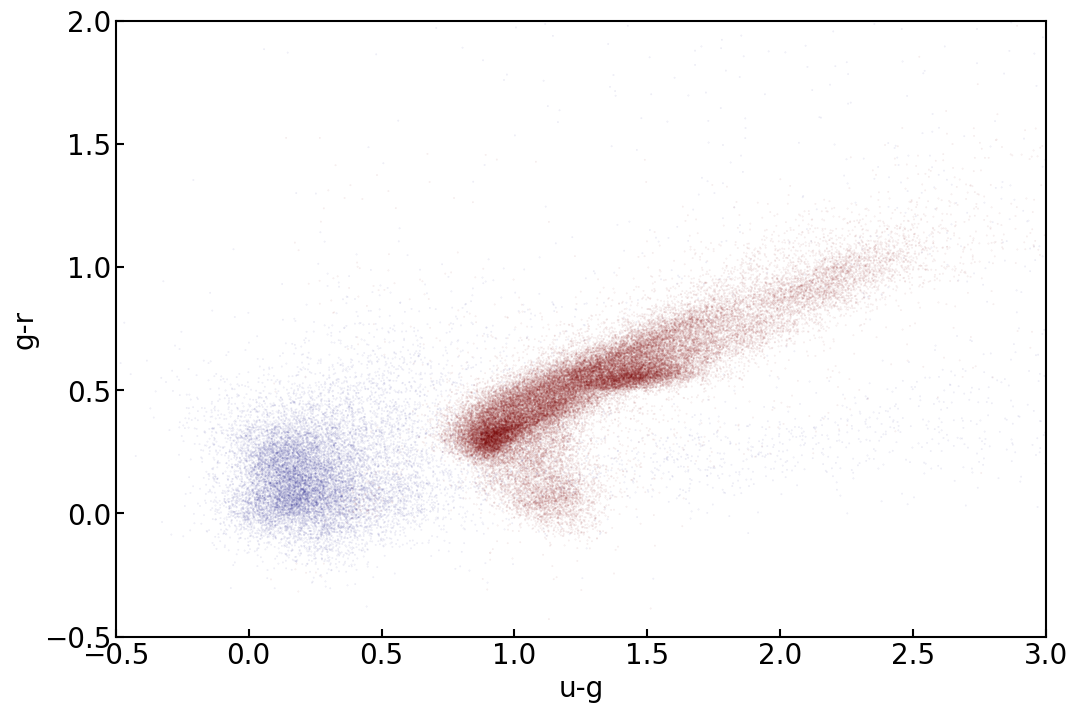

In [187]:
# Colour-colour view of the TRAINING set (colour = class). Two of the four inputs shown.
plt.figure(figsize=(12, 8))
plt.scatter(colors_trainval[train_idx][:, 0], colors_trainval[train_idx][:, 1],
            c=labels_trainval[train_idx], s=0.1, alpha=0.1, cmap=cm.jet_r)  # colour by class
plt.xlim(-0.5, 3); plt.ylim(-0.5, 2)
plt.xlabel('u-g'); plt.ylabel('g-r')

### 2.2 Define the network

In [193]:
class fully_connected_NN_QSO_star(torch.nn.Module):
    def __init__(self):
        super(fully_connected_NN_QSO_star, self).__init__()

        # Layer 1: 4 input colours -> 10 hidden units, then a ReLU non-linearity.
        self.fc1 = torch.nn.Sequential(torch.nn.Linear(4, 10), torch.nn.ReLU())
       
        # Layer 2: 10 -> 2 hidden units.
        self.fc2 = torch.nn.Sequential(torch.nn.Linear(10, 2))

    def forward(self, x):
        x = self.fc1(x)   # first hidden layer
        x = self.fc2(x)   # output logits, shape [N, 2]
        
        return x

In [194]:
def accuracy(model, X, y):
    # Fraction of correct predictions, evaluated WITHOUT tracking gradients (fast, low memory).
    model.eval()                                # evaluation mode
    with torch.no_grad():                       # do not build the autograd graph
        logits = model(X)                       # forward pass -> logits [N, 2]
        pred   = torch.max(logits, 1)[1]        # index of the largest logit = predicted class
        acc    = (pred == y).float().mean().item()  # compare to truth, average, to Python float
    return acc

In [195]:
def completeness_purity(true_value, prediction):
    # true_value / prediction: 1D numpy arrays of 0/1 labels. Convention: class 1 = QSO.
    n_true_qso   = np.sum(true_value == 1)                        # number of real QSOs
    n_qso_as_qso = np.sum((true_value == 1) & (prediction == 1))  # real QSOs correctly found
    n_pred_qso   = np.sum(prediction == 1)                        # objects the model calls QSO

    completeness = n_qso_as_qso / n_true_qso   # fraction of real QSOs recovered  (recall)
    purity       = n_qso_as_qso / n_pred_qso   # fraction of QSO calls that are real (precision)
    return completeness, purity

In [198]:
model = fully_connected_NN_QSO_star().to(device)   # build the model on the device
learningRate = 0.05                                # step size
epochs = 300                                     # passes over the training set
batch_size = 1024                                  # mini-batch size

criterion = torch.nn.CrossEntropyLoss()            # logits + integer targets -> loss
optimizer = torch.optim.SGD(model.parameters(), lr=learningRate)  # SGD

### 2.3 Train — fit on TRAIN, monitor on VALIDATION (never touch test here)

In [199]:
# Records for the learning curves.
epoch_array      = []
loss_train_array = []; loss_val_array = []
acc_train_array  = []; acc_val_array  = []

N_train = len(color_train)          # number of training examples
start_time = time.time()
print("epoch  train_acc  train_loss   val_acc   val_loss")

for epoch in range(epochs):
    model.train()                                   # training mode
    # --- mini-batch gradient descent over the TRAINING set only ---
    for start in range(0, N_train, batch_size):
        end = min(start + batch_size, N_train)      # last batch may be shorter        
        optimizer.zero_grad()                       # clear old gradients
        outputs = model(color_train[start:end])     # forward pass on this batch
        loss = criterion(outputs, label_train[start:end])  # batch loss (logits + int labels)
        loss.backward()                             # backprop
        optimizer.step()                            # update weights

    # --- after each epoch, record loss on TRAIN and VALIDATION (never on test) ---
    model.eval()
    with torch.no_grad():
        l_tr  = criterion(model(color_train), label_train).item()   # training loss
        l_val = criterion(model(color_val),   label_val).item()     # validation loss
    a_tr  = accuracy(model, color_train, label_train)               # training accuracy
    a_val = accuracy(model, color_val,   label_val)                 # validation accuracy

    epoch_array.append(epoch)
    loss_train_array.append(l_tr); loss_val_array.append(l_val)
    acc_train_array.append(a_tr);  acc_val_array.append(a_val)

    if epoch % 50 == 0:                             # print progress every 50 epochs
        print(f"{epoch:5d}   {a_tr:.4f}     {l_tr:.4f}      {a_val:.4f}    {l_val:.4f}")

print("training time (s):", time.time() - start_time)

epoch  train_acc  train_loss   val_acc   val_loss
    0   0.7557     0.5150      0.7598    0.5104
   50   0.9767     0.0905      0.9773    0.0883
  100   0.9800     0.0810      0.9806    0.0783
  150   0.9807     0.0770      0.9814    0.0734
  200   0.9812     0.0736      0.9818    0.0697
  250   0.9814     0.0702      0.9817    0.0661
training time (s): 3.860740900039673


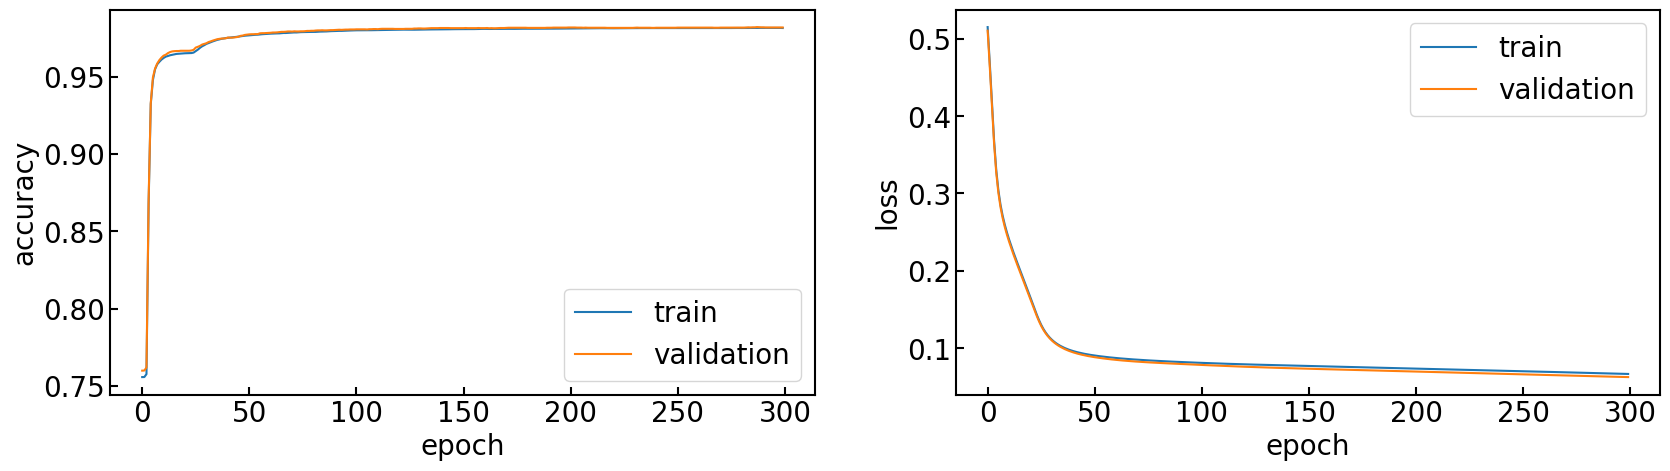

In [200]:
# Learning curves. If the TRAIN curve keeps improving while the VALIDATION curve
# stalls or worsens, that gap is overfitting -- and it is why we hold out a test set.
plt.figure(figsize=(20, 5))
plt.subplot(1, 2, 1)
plt.plot(epoch_array, acc_train_array, label='train')
plt.plot(epoch_array, acc_val_array,   label='validation')
plt.xlabel('epoch'); plt.ylabel('accuracy'); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epoch_array, loss_train_array, label='train')
plt.plot(epoch_array, loss_val_array,   label='validation')
plt.xlabel('epoch'); plt.ylabel('loss'); plt.legend()

In [201]:
model.eval()                                    # evaluation mode
with torch.no_grad():                       # do not build the autograd graph
    probs = torch.softmax(model(color_val), dim=1)   # shape [N, 2], rows sum to 1
    p_qso = probs[:, 1].detach().cpu().numpy()       # probability of the QSO class

(-0.5, 1.5)

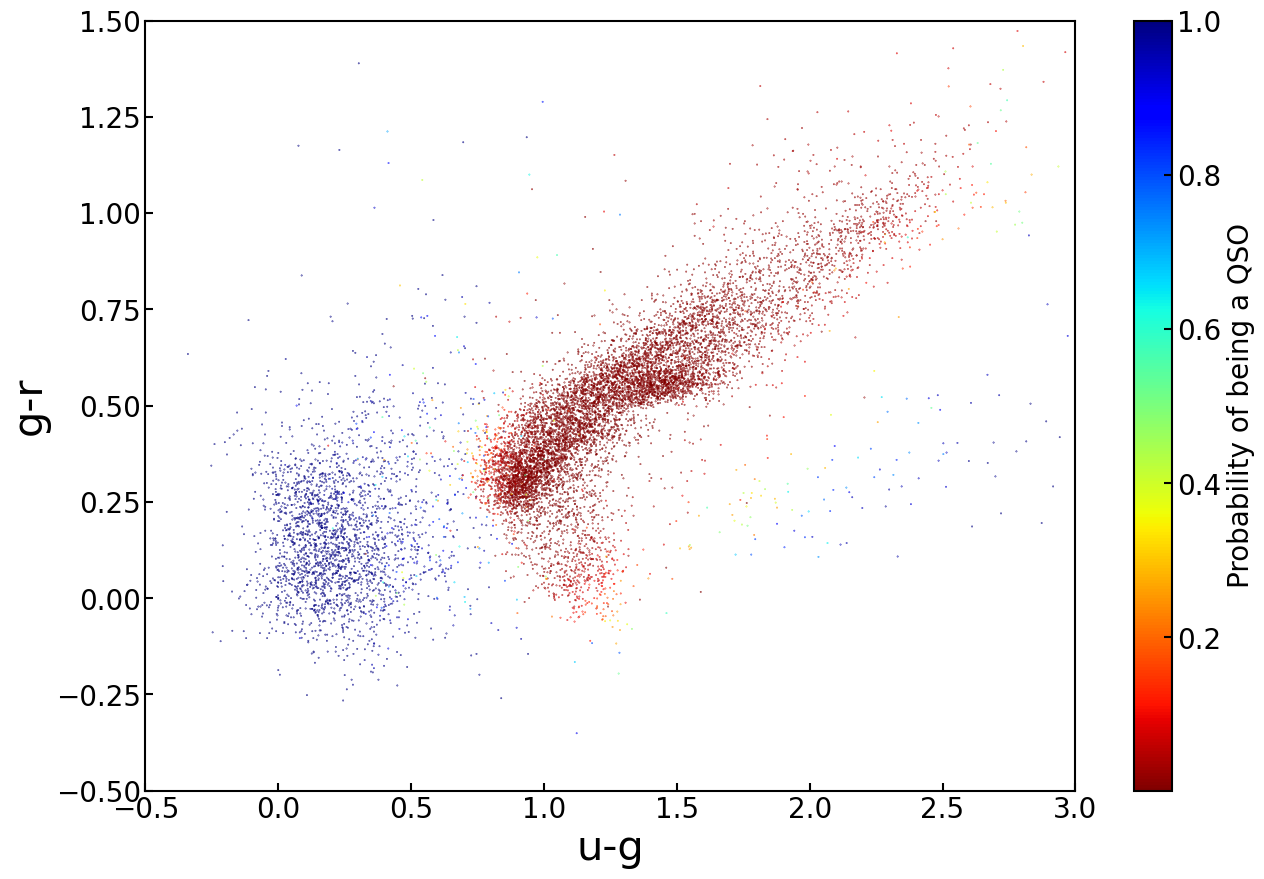

In [202]:
plt.figure(figsize=(15,10))

plt.scatter(colors_trainval[val_idx][:,0],colors_trainval[val_idx][:,1],s=0.1,c=p_qso,cmap=cm.jet_r)
plt.colorbar(label='Probability of being a QSO')
plt.xlabel('u-g',fontsize=30)
plt.ylabel('g-r',fontsize=30)
plt.xlim(-0.5,3)
plt.ylim(-0.5,1.5)

In [203]:
# Validation, for the completeness/purity report.
print("held-out validation accuracy:", round(acc_val_array[-1], 4))

model.eval()
with torch.no_grad():
    pred_val = torch.max(model(color_val), 1)[1].cpu().numpy()   # predicted classes
true_val = label_val.cpu().numpy()                              # true classes
comp, pur = completeness_purity(true_val, pred_val)
print(f"completeness = {comp:.4f}   purity = {pur:.4f}   C*P = {comp*pur:.4f}")

held-out validation accuracy: 0.9818
completeness = 0.9359   purity = 0.9876   C*P = 0.9243


### 2.4 Final evaluation — ONE-SHOT on the held-out test setOnly now, with the architecture, learning rate and epoch count already locked in(using the validation set), do we touch the test set. This single number is the honest estimate of how the model does on genuinely unseen data.

In [207]:
# Predictions on the TEST set only, for the completeness/purity report.
model.eval()
with torch.no_grad():
    pred_test = torch.max(model(color_test), 1)[1].cpu().numpy()   # predicted classes
true_test = label_test.cpu().numpy()                              # true classes

test_acc = accuracy(model, color_test, label_test)   # the ONLY time we use the test set
print("held-out test accuracy:", round(test_acc, 4))
comp, pur = completeness_purity(true_test, pred_test)
print(f"completeness = {comp:.4f}   purity = {pur:.4f}   C*P = {comp*pur:.4f}")

held-out test accuracy: 0.9809
completeness = 0.9375   purity = 0.9854   C*P = 0.9238


### Exercise



Improve the network so that, **on the validation set**, accuracy > 0.99 and completeness × purity > 0.966. Try things like: more hidden units, an extra layer,a different learning rate, more epochs, or the Adam optimiser(`torch.optim.Adam(model.parameters(), lr=...)`).Only after you have settled on your best model using the validation set, run thetest-set cells **once** and report those numbers — that is your honest performance.